# Alanyze data using behavioral model
There are 3 models with different parameter combinations:

1. <b>The Bayesian model (Schwöbel et al. 2021):</b> \
   <b>a.</b> With 3 parameters: a policy forgetting rate $\lambda_{\pi}$, a reward forgetting rate $\lambda_{r}$, and a decision temparature $\beta$. \
   <b>b.</b> With 4 parameters: a policy forgetting rate $\lambda_{\pi}$, a reward forgetting rate $\lambda_{r}$, a decision temparature $\beta$, and a habitual tendency $h$.
2. <b>A newer MF/MB version that is better for fitting (Otto et al. 2013):</b> \
<b>Note:</b> This is not quite the original version, as the Q-values in the original work did not converge to the true expected values. Instead, I implemented a "bug-fixed" version.\
   <b>a.</b> With 4 parameters: a MF weight parameter $\beta_{MF}$, a MB weight parameter $\beta_{MB}$, a learning rate $\alpha$, and a dicount factor $\lambda$. \
   <b>b.</b> With 5 parameters: a MF weight parameter $\beta_{MF}$, a MB weight parameter $\beta_{MB}$, a learning rate $\alpha$, and a dicount factor $\lambda$$, and a repetition/perserveration parameter $p$. \
3. <b>The original model-free/model-based (MF/MB) model (Daw et al. 2005, 2011):</b> \
   <b>a.</b> With 4 parameters: a weighting parameters $\omega$, a decision temperature $\beta$, a learning rate $\alpha$, and a dicount factor $\lambda$. \
   <b>b.</b> With 5 parameters: a weighting parameter $\omega$, a decision temperature $\beta$, a learning rate $\alpha$, a dicount factor $\lambda$, and a repetition/perserveration parameter $p$.

Tell python that the code in the submodule is code that we want to import and run

In [1]:
import sys
import os
current_dir = os.path.abspath('')
os.chdir(current_dir)
sys.path.append(os.path.join(current_dir,'..','code','BalancingControl'))

import two_stage_utils as tu
import inference as inf
import inference_utils as iu

torch threads 1


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running on device cpu
torch threads 1


Other imports that we need for simulation, inference, and plotting

In [2]:
import torch
import pyro

import os
from scipy.io import loadmat
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd
import glob
import json
import gc
import pickle

Where second stage random walks from the experiment are stored

In [3]:
Rho_data_fname = os.path.join("experiment", "dawrandomwalks.mat")

Define where results should be saved

In [4]:
results_folder = "results"
inference_folder = os.path.join(results_folder, "inference")

In [5]:
processed_data_folder = "processed_data"

full_data_fname = "full_data.csv"
full_data_file = os.path.join(processed_data_folder, full_data_fname)

full_data_df = pd.read_csv(full_data_file)

statistics_folder = os.path.join(results_folder, "statistics")

scores_file_name = "scores.csv"
scores_file = os.path.join(statistics_folder, scores_file_name)

In [6]:
# number of simulated agents/participants
n_agents = int(full_data_df['subject'].max()+1)
print(n_agents)

print(full_data_df.keys())

188
Index(['Unnamed: 0', 'first_stage_actions', 'second_stage_actions',
       'first_stage_rewards', 'second_stage_rewards', 'first_stage_states',
       'second_stage_states', 'miniblock_index', 'step_index',
       'common_transition', 'mask', 'repeated_actions', 'rewarded', 'subject'],
      dtype='object')


In [7]:
def convert_data_for_agent(full_data_df):

    mask = full_data_df.loc[(full_data_df["step_index"]==1)]
    mask_formatted = torch.stack([torch.from_numpy(mask.loc[mask["subject"]==i]["mask"].to_numpy()) for i in range(n_agents)])

    actions1 = full_data_df.loc[(full_data_df["step_index"]==1)]
    actions1_formatted = torch.stack([torch.from_numpy(actions1.loc[actions1["subject"]==i]["first_stage_actions"].to_numpy()) for i in range(n_agents)])

    actions2 = full_data_df.loc[(full_data_df["step_index"]==2)]
    actions2_formatted = torch.stack([torch.from_numpy(actions2.loc[actions2["subject"]==i]["second_stage_actions"].to_numpy()) for i in range(n_agents)])

    print("possible actions1", torch.unique(actions1_formatted[mask_formatted]))
    print("possible actions2", torch.unique(actions2_formatted[mask_formatted]))

    # write minus one into invalid regions (currently returns integer overflow below when converted to int)
    actions1_formatted = torch.where(mask_formatted, actions1_formatted, -1)
    actions2_formatted = torch.where(mask_formatted, actions2_formatted, -1)

    actions = torch.stack([actions1_formatted, actions2_formatted], dim=-1).permute((1,2,0))
    #print(actions.permute((0,2,1))[mask_formatted])
    # agent counts from zero:
    actions = actions-1.

    states1 = full_data_df.loc[(full_data_df["step_index"]==1)]
    # agent counts from zero, hence -1 at the end:
    states1_formatted = torch.stack([torch.from_numpy(states1.loc[states1["subject"]==i]["first_stage_states"].to_numpy()) for i in range(n_agents)]) - 1
     
    states2 = full_data_df.loc[(full_data_df["step_index"]==2)]
    # agent counts from zero, hence -1 at the end:
    states2_formatted = torch.stack([torch.from_numpy(states2.loc[states2["subject"]==i]["second_stage_states"].to_numpy()) for i in range(n_agents)]) - 1

    # write minus one into invalid regions (currently returns integer overflow below when converted to int)
    states1_formatted = torch.where(mask_formatted, states1_formatted, -1)
    states2_formatted = torch.where(mask_formatted, states2_formatted, -1)
    # create third time step states:
    states3_formatted = states2_formatted+2 + (actions2_formatted-1)*2
    states3_formatted = torch.where(mask_formatted, states3_formatted, -1)


    print("possible states1", torch.unique(states1_formatted[mask_formatted]))
    print("possible states2", torch.unique(states2_formatted[mask_formatted]))
    print("possible states3", torch.unique(states3_formatted[mask_formatted]))

    states = torch.stack([states1_formatted, states2_formatted, states3_formatted], dim=-1).permute((1,2,0))

    # agent views r=2 as "no reward", may instead give negative reward as in Otto et al:
    rewards1_formatted = torch.zeros_like(states1_formatted) #+ 2

    rewards2_formatted = rewards1_formatted

    # create third time step rewards = second stage rewards:
    rewards3 = full_data_df.loc[(full_data_df["step_index"]==2)]
    rewards3_formatted = torch.stack([torch.from_numpy(rewards3.loc[rewards3["subject"]==i]["second_stage_rewards"].to_numpy()) for i in range(n_agents)])

    print("possible rewards1", torch.unique(rewards1_formatted[mask_formatted]))
    print("possible rewards2", torch.unique(rewards2_formatted[mask_formatted]))
    print("possible rewards3", torch.unique(rewards3_formatted[mask_formatted]))

    # write minus one into invalid regions (currently returns integer overflow below when converted to int)
    rewards1_formatted = torch.where(mask_formatted, rewards1_formatted, -1)
    rewards2_formatted = torch.where(mask_formatted, rewards2_formatted, -1)
    rewards3_formatted = torch.where(mask_formatted, rewards3_formatted, -1)

    rewards = torch.stack([rewards1_formatted, rewards2_formatted, rewards3_formatted], dim=-1).permute((1,2,0))


    data_dict = {"observations": states.long(), "rewards": rewards.long(), "actions": actions.long(), "valid": mask_formatted.permute((1,0))}

    return data_dict

data = convert_data_for_agent(full_data_df)

print(data)

possible actions1 tensor([1., 2.], dtype=torch.float64)
possible actions2 tensor([1., 2.], dtype=torch.float64)


possible states1 tensor([0.], dtype=torch.float64)
possible states2 tensor([1., 2.], dtype=torch.float64)
possible states3 tensor([3., 4., 5., 6.], dtype=torch.float64)


possible rewards1 tensor([0.], dtype=torch.float64)
possible rewards2 tensor([0.], dtype=torch.float64)
possible rewards3 tensor([0., 1.], dtype=torch.float64)
{'observations': tensor([[[ 0,  0,  0,  ..., -1,  0, -1],
         [ 1,  1,  2,  ..., -1,  1, -1],
         [ 3,  3,  4,  ..., -1,  5, -1]],

        [[ 0,  0,  0,  ...,  0,  0,  0],
         [ 1,  1,  2,  ...,  1,  1,  2],
         [ 5,  3,  6,  ...,  3,  3,  4]],

        [[ 0,  0,  0,  ...,  0,  0,  0],
         [ 1,  1,  2,  ...,  2,  2,  1],
         [ 5,  3,  6,  ...,  6,  6,  3]],

        ...,

        [[ 0,  0,  0,  ...,  0,  0,  0],
         [ 1,  1,  2,  ...,  1,  2,  1],
         [ 3,  5,  4,  ...,  3,  6,  3]],

        [[ 0,  0, -1,  ...,  0,  0, -1],
         [ 1,  2, -1,  ...,  2,  1, -1],
         [ 3,  4, -1,  ...,  6,  3, -1]],

        [[-1,  0,  0,  ...,  0,  0,  0],
         [-1,  2,  1,  ...,  1,  1,  2],
         [-1,  4,  3,  ...,  3,  3,  4]]]), 'rewards': tensor([[[ 0,  0,  0,  ..., -1,  0, -1],
      

#### Global experiment parameters

In [8]:
# number of simulated agents/participants
n_agents = 188

In [9]:
trials =  201#number of trials
T = 3 #number of time steps in each trial
nb = 4 # number of bandits, ie second level rewards
ns = 3+nb #number of states
no = ns #number of observations
na = 2 #number of actions
npi = na**(T-1) #number of policies
nr = 2 #number of rewards
never_reward = ns-nb # states that dont generate rewards

# prob for invalid answer (e.g. no reply). Same frequency as in the real data
p_valid = 1.-1./201.

# make global parameter dict:
global_experiment_parameters = {"trials": trials, "T": T, "nb": nb, "ns": ns, "no": no, "na": na, "npi": npi, "nr": nr, "never_reward": never_reward, "p_invalid": p_valid}

Define states and transition matrices

In [10]:
#generating probability of observations in each state / unity matrix
A = torch.eye(no)


#state transition generative probability (matrix)
B = torch.zeros((ns, ns, na))
b1 = 0.7
nb1 = 1.-b1
b2 = 0.7
nb2 = 1.-b2

B[:,:,0] = torch.tensor([[  0,  0,  0,  0,  0,  0,  0,],
                         [ b1,  0,  0,  0,  0,  0,  0,],
                         [nb1,  0,  0,  0,  0,  0,  0,],
                         [  0,  1,  0,  1,  0,  0,  0,],
                         [  0,  0,  1,  0,  1,  0,  0,],
                         [  0,  0,  0,  0,  0,  1,  0,],
                         [  0,  0,  0,  0,  0,  0,  1,],])

B[:,:,1] = torch.tensor([[  0,  0,  0,  0,  0,  0,  0,],
                         [nb2,  0,  0,  0,  0,  0,  0,],
                         [ b2,  0,  0,  0,  0,  0,  0,],
                         [  0,  0,  0,  1,  0,  0,  0,],
                         [  0,  0,  0,  0,  1,  0,  0,],
                         [  0,  1,  0,  0,  0,  1,  0,],
                         [  0,  0,  1,  0,  0,  0,  1,],])

# add to parameter dict
global_experiment_parameters["A"] = A
global_experiment_parameters["B"] = B

Load and plot reward probabilities

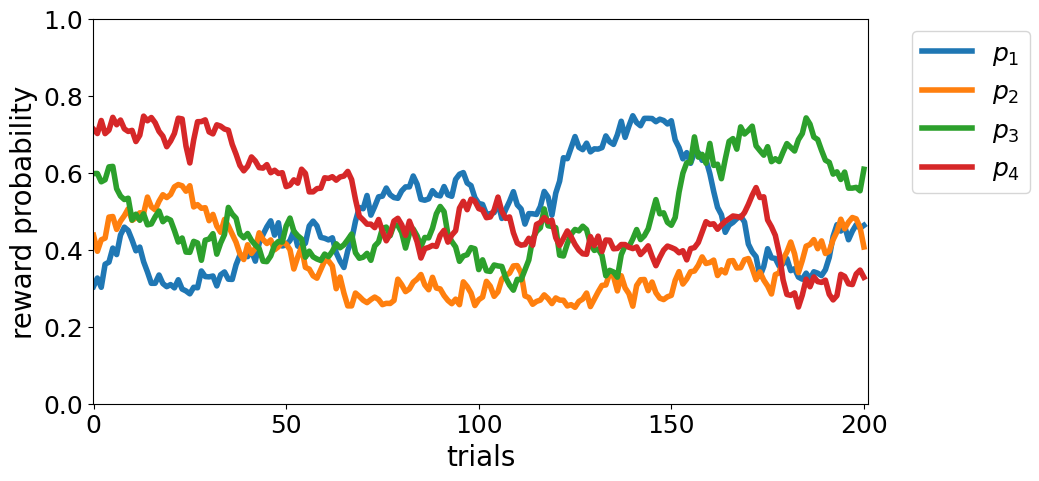

In [11]:
rew_probs = loadmat(Rho_data_fname)['dawrandomwalks']
assert trials==rew_probs.shape[-1]

Rho = torch.zeros((trials, nr, ns))

Rho[:,1,:never_reward] = 0.
Rho[:,0,:never_reward] = 1.

Rho[:,1,never_reward:never_reward+2] = torch.from_numpy(rew_probs[0,:,:]).permute((1,0))
Rho[:,0,never_reward:never_reward+2] = torch.from_numpy(1-rew_probs[0,:,:]).permute((1,0))

Rho[:,1,never_reward+2:] = torch.from_numpy(rew_probs[1,:,:]).permute((1,0))
Rho[:,0,never_reward+2:] = torch.from_numpy(1-rew_probs[1,:,:]).permute((1,0))

plt.figure(figsize=(10,5))
for i in range(4):
    plt.plot(Rho[:,1,3+i], label="$p_{}$".format(i+1), linewidth=4)
plt.ylim([0,1])
plt.yticks(torch.arange(0,1.1,0.2),fontsize=18)
plt.ylabel("reward probability", fontsize=20)
plt.xlim([-0.1, trials+0.1])
plt.xticks(range(0,trials+1,50),fontsize=18)
plt.xlabel("trials", fontsize=20)
plt.legend(fontsize=18, bbox_to_anchor=(1.04,1))
plt.savefig(os.path.join(results_folder, "twostep_prob.svg"),dpi=300)
plt.show()

# add to parameter dict
global_experiment_parameters["Rho"] = Rho

### load behavioral outputs of participants: mf-/mb-scores

In [12]:
scores_df = pd.read_csv(scores_file).drop(columns='Unnamed: 0')

Now we can start :) 

### 2. MF/MB:
### 2.a 4 parameter version

Agent pre-setup

In [13]:
# set parameters and their names
learn_prior = True

use_orig = True

use_p = False
restrict_alpha = False
max_dt = 6

use_w = True

n_pars = 4

prefix = "MFMB"
agnt_str = ""

if use_orig:
    agnt_str += "_mf_mb_Orig"
    param_names = ["discount", "learning rate", "dec temp", "weight"]
    model_name = "original original w and beta model"
    if use_w:
        param_ranges = [[0,1], [0,1], [0,8], [0,1]]
    else:
        param_ranges = [[0,1], [0,1], [0,8], [0,8]]
else:
    agnt_str += "_mf_mb"
    param_names = ["mb weight", "discount", "mf weight", "learning rate"]
    model_name = "two beta mbmf model"
    param_ranges = [[0,max_dt], [0,1], [0,max_dt], [0,1]]


if learn_prior:
    n_pars += 2
    param_names += ["prior lr", "prior weight"]
    param_ranges += [[0,1], [0,max_dt]]
    agnt_str += "_prior"

if use_p:
    n_pars += 1
    agnt_str += "_p"
    param_names += ["repetition"]
    
if restrict_alpha:
    agnt_str += "_resticted"
    min_alpha = 0.1
else:
    min_alpha = 0

# prepare for saving results
# make base filename and folder string
agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str
print(agent_type)
fname_base = agent_type+"_inference_"
print(fname_base)
# define folder where we want to save data
base_dir = os.path.join(inference_folder,fname_base[:-1])

MFMB_6pars_mf_mb_Orig_prior
MFMB_6pars_mf_mb_Orig_prior_inference_


#### Inference

Inference pre-setup

In [14]:
# prepare for saving results
# make base filename and folder string
fname_base = agent_type+"_inference_"
print(fname_base)
# define folder where we want to save data
base_dir = os.path.join(inference_folder,fname_base[:-1])

# make directory if it doesnt exist
if fname_base[:-1] not in os.listdir(inference_folder):
    os.mkdir(base_dir)

# how many inference steps
num_steps = 600

MFMB_6pars_mf_mb_Orig_prior_inference_


<b>Decide</b> for running or loading inference

In [15]:
run_inference = True

<b>Either:</b> Set up agent and inference. Run main inference loop, plot intermediate and end results

analyzing 188 data sets
this is inference using <class 'inference.GeneralGroupInference'>
taking steps 1 to 100 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 57584.39:   0%|          | 0/100 [00:10<?, ?it/s]

Mean ELBO 57584.39:   1%|          | 1/100 [00:10<17:32, 10.63s/it]

Mean ELBO 57043.75:   1%|          | 1/100 [00:18<17:32, 10.63s/it]

...

Mean ELBO 44557.14:  98%|█████████▊| 98/100 [13:42<00:16,  8.41s/it]

Mean ELBO 44557.14:  99%|█████████▉| 99/100 [13:42<00:08,  8.42s/it]

Mean ELBO 44496.12:  99%|█████████▉| 99/100 [13:50<00:08,  8.42s/it]

Mean ELBO 44496.12: 100%|██████████| 100/100 [13:50<00:00,  8.41s/it]

Mean ELBO 44496.12: 100%|██████████| 100/100 [13:50<00:00,  8.31s/it]

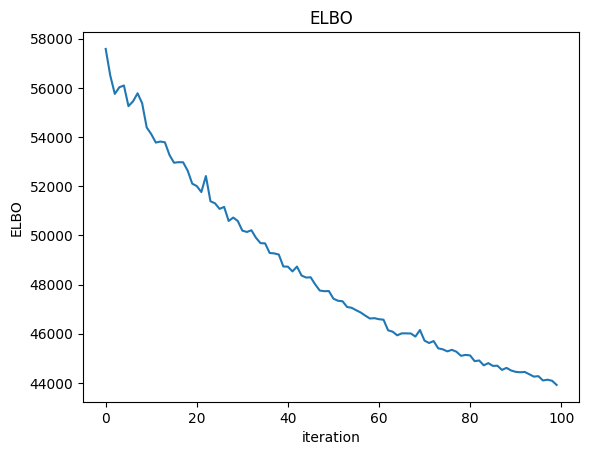

taking steps 101 to 200 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 44003.97:   0%|          | 0/100 [00:08<?, ?it/s]

Mean ELBO 44003.97:   1%|          | 1/100 [00:08<14:07,  8.56s/it]

Mean ELBO 43978.87:   1%|          | 1/100 [00:16<14:07,  8.56s/it]

...

Mean ELBO 42123.22:  98%|█████████▊| 98/100 [13:24<00:16,  8.05s/it]

Mean ELBO 42123.22:  99%|█████████▉| 99/100 [13:24<00:08,  8.04s/it]

Mean ELBO 42116.45:  99%|█████████▉| 99/100 [13:32<00:08,  8.04s/it]

Mean ELBO 42116.45: 100%|██████████| 100/100 [13:32<00:00,  8.06s/it]

Mean ELBO 42116.45: 100%|██████████| 100/100 [13:32<00:00,  8.13s/it]

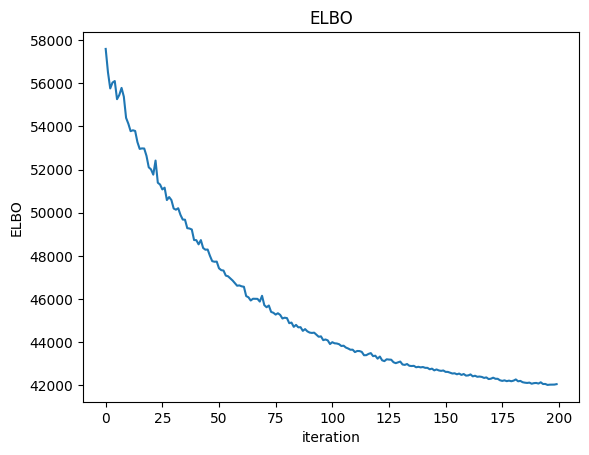

taking steps 201 to 300 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 42033.78:   0%|          | 0/100 [00:08<?, ?it/s]

Mean ELBO 42033.78:   1%|          | 1/100 [00:08<13:25,  8.14s/it]

Mean ELBO 42031.14:   1%|          | 1/100 [00:16<13:25,  8.14s/it]

...

Mean ELBO 41524.81:  98%|█████████▊| 98/100 [13:17<00:16,  8.07s/it]

Mean ELBO 41524.81:  99%|█████████▉| 99/100 [13:17<00:08,  8.06s/it]

Mean ELBO 41522.32:  99%|█████████▉| 99/100 [13:25<00:08,  8.06s/it]

Mean ELBO 41522.32: 100%|██████████| 100/100 [13:25<00:00,  8.06s/it]

Mean ELBO 41522.32: 100%|██████████| 100/100 [13:25<00:00,  8.06s/it]

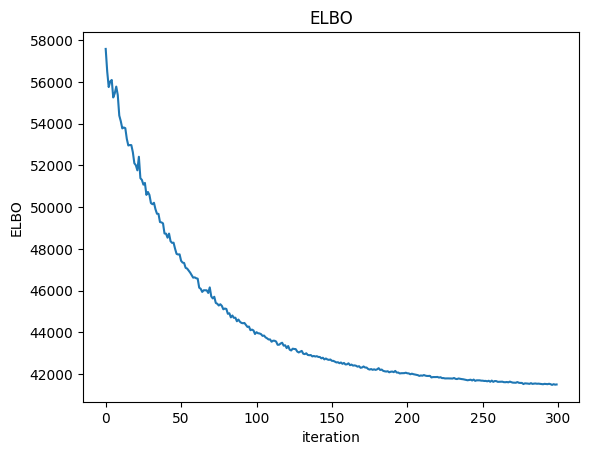

taking steps 301 to 400 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 41479.95:   0%|          | 0/100 [00:08<?, ?it/s]

Mean ELBO 41479.95:   1%|          | 1/100 [00:08<13:19,  8.08s/it]

Mean ELBO 41486.48:   1%|          | 1/100 [00:16<13:19,  8.08s/it]

...

Mean ELBO 41301.25:  98%|█████████▊| 98/100 [13:17<00:15,  7.99s/it]

Mean ELBO 41301.25:  99%|█████████▉| 99/100 [13:17<00:07,  7.99s/it]

Mean ELBO 41300.13:  99%|█████████▉| 99/100 [13:25<00:07,  7.99s/it]

Mean ELBO 41300.13: 100%|██████████| 100/100 [13:25<00:00,  7.96s/it]

Mean ELBO 41300.13: 100%|██████████| 100/100 [13:25<00:00,  8.05s/it]

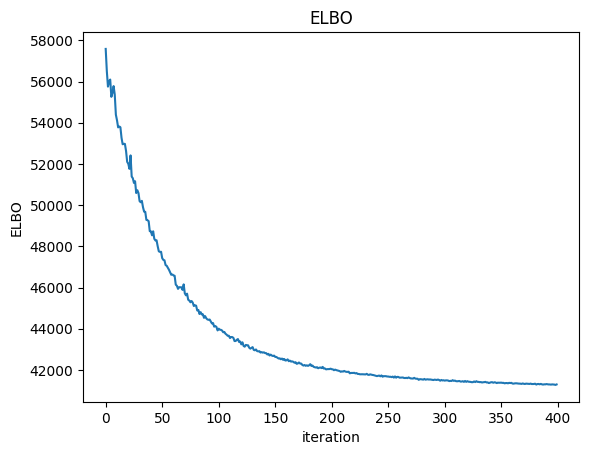

taking steps 401 to 500 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 41277.89:   0%|          | 0/100 [00:08<?, ?it/s]

Mean ELBO 41277.89:   1%|          | 1/100 [00:08<13:28,  8.17s/it]

Mean ELBO 41285.44:   1%|          | 1/100 [00:16<13:28,  8.17s/it]

...

Mean ELBO 41199.79:  98%|█████████▊| 98/100 [12:56<00:15,  7.83s/it]

Mean ELBO 41199.79:  99%|█████████▉| 99/100 [12:56<00:07,  7.80s/it]

Mean ELBO 41199.31:  99%|█████████▉| 99/100 [13:04<00:07,  7.80s/it]

Mean ELBO 41199.31: 100%|██████████| 100/100 [13:04<00:00,  7.82s/it]

Mean ELBO 41199.31: 100%|██████████| 100/100 [13:04<00:00,  7.85s/it]

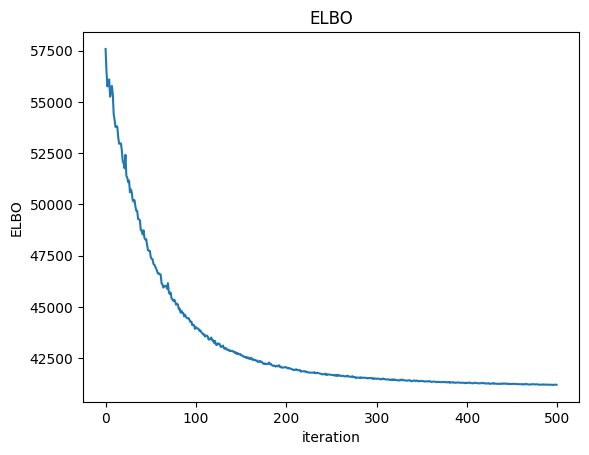

taking steps 501 to 600 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 41196.20:   0%|          | 0/100 [00:07<?, ?it/s]

Mean ELBO 41196.20:   1%|          | 1/100 [00:07<12:50,  7.78s/it]

Mean ELBO 41196.05:   1%|          | 1/100 [00:15<12:50,  7.78s/it]

...

Mean ELBO 41142.46:  98%|█████████▊| 98/100 [12:44<00:15,  7.61s/it]

Mean ELBO 41142.46:  99%|█████████▉| 99/100 [12:44<00:07,  7.61s/it]

Mean ELBO 41141.76:  99%|█████████▉| 99/100 [12:52<00:07,  7.61s/it]

Mean ELBO 41141.76: 100%|██████████| 100/100 [12:52<00:00,  7.57s/it]

Mean ELBO 41141.76: 100%|██████████| 100/100 [12:52<00:00,  7.72s/it]

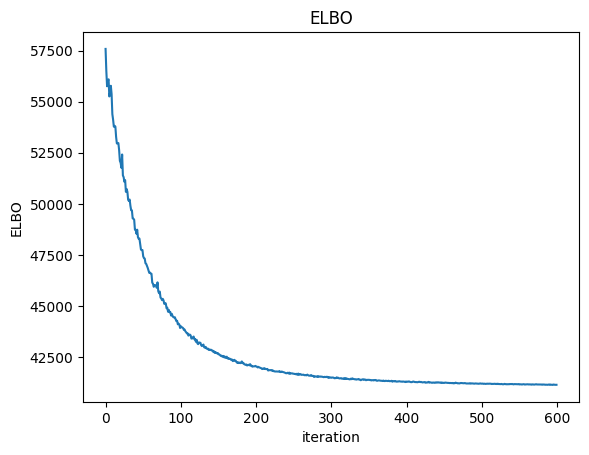

       discount  learning rate  dec temp    weight  prior weight  prior lr  \
0      0.752155       0.707099  2.393577  0.534629      1.198772  0.481768   
1      0.830712       0.778551  4.697453  0.790015      0.946401  0.770433   
2      0.783257       0.565199  1.237242  0.920308      0.931740  0.155091   
3      0.746527       0.176045  3.336852  0.605333      1.751304  0.315780   
4      0.146587       0.935757  2.203038  0.955585      1.099842  0.676447   
...         ...            ...       ...       ...           ...       ...   
93995  0.066682       0.596777  0.324145  0.615244      0.419308  0.155678   
93996  0.405973       0.881300  1.550738  0.830421      1.246609  0.874706   
93997  0.818095       0.829020  5.023892  0.923538      0.876171  0.912956   
93998  0.862145       0.621719  5.394614  0.965961      0.577177  0.180354   
93999  0.026404       0.154852  0.763262  0.878252      0.884139  0.599949   

       subject  
0            0  
1            1  
2           

<Figure size 640x480 with 0 Axes>

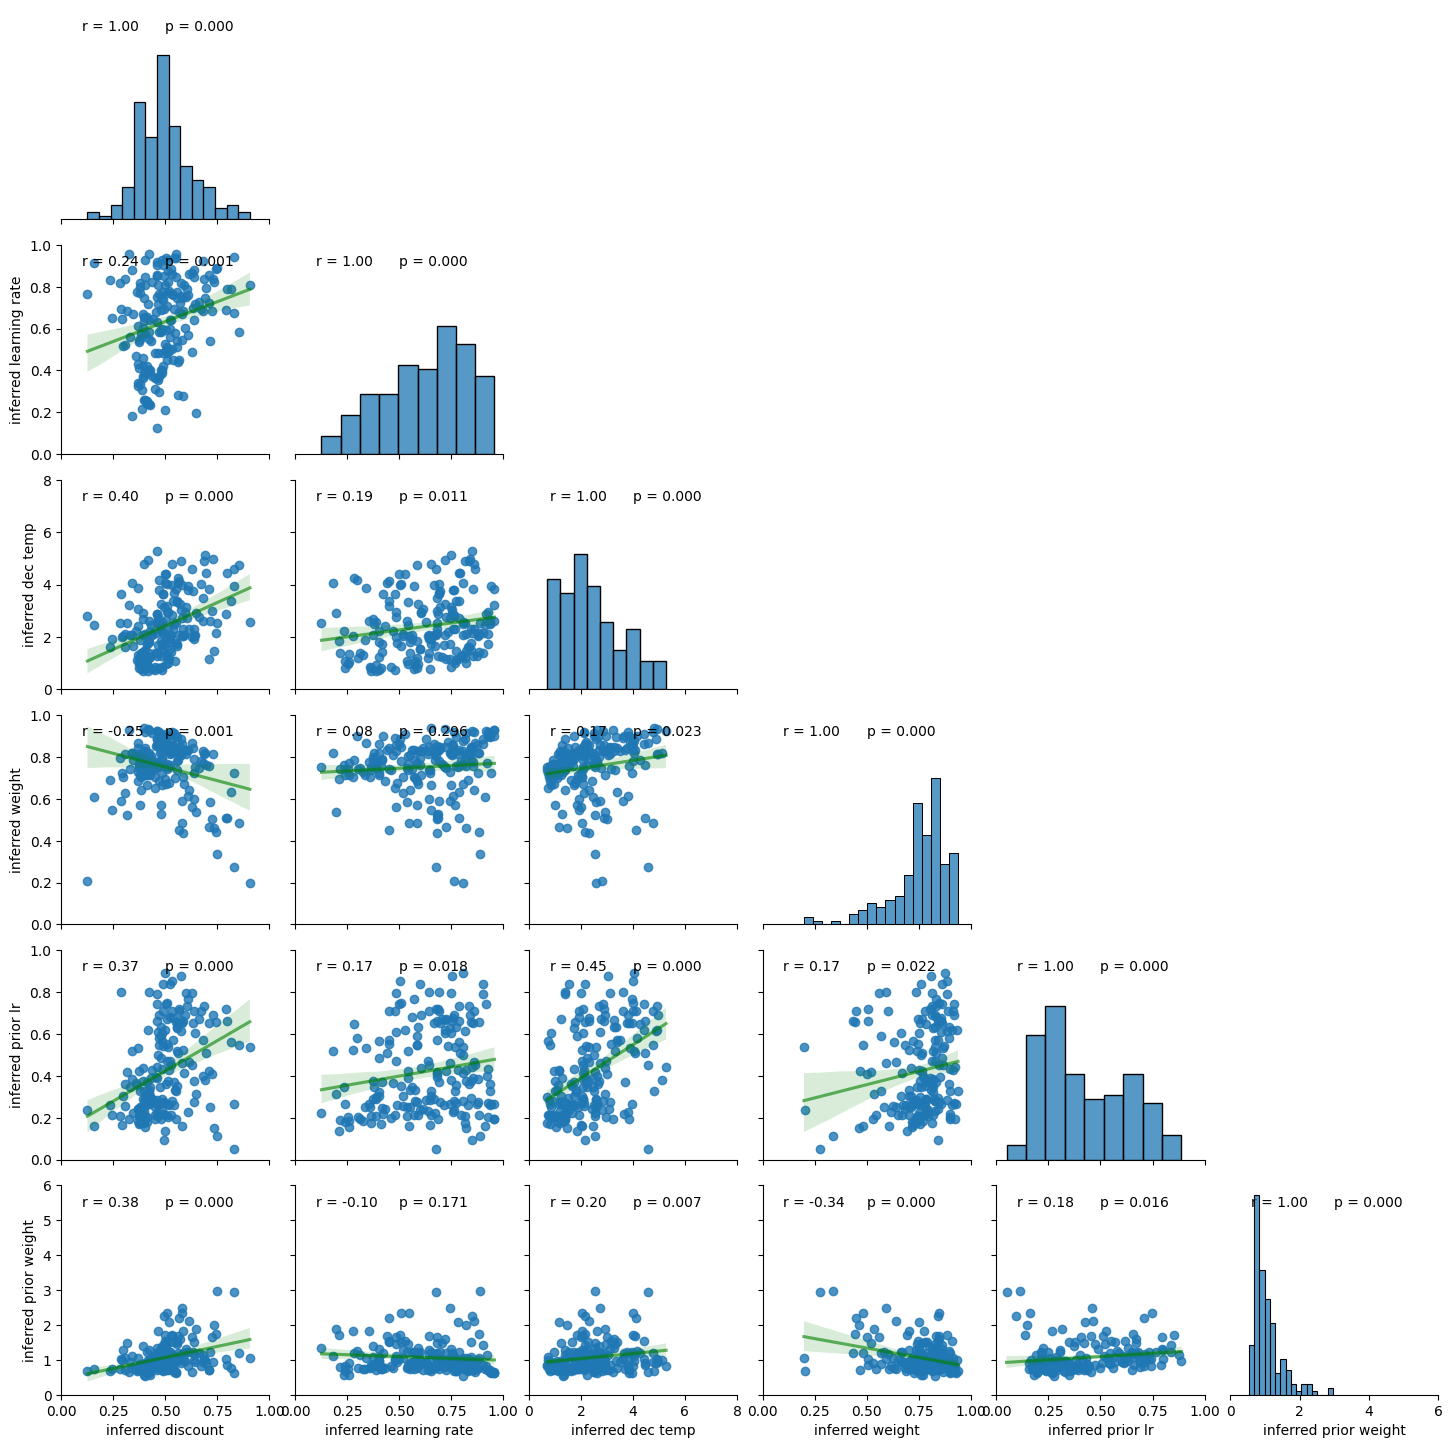

In [16]:
if run_inference:

    # remove old inference?
    remove_old = True

    # set up agent
    bayes_agent = tu.set_up_mbmf_inference_agent(n_agents, learn_prior, use_orig, use_p, restrict_alpha, max_dt, min_alpha, 
                                                base_dir, global_experiment_parameters, data["valid"], use_w=use_w, remove_old=remove_old)

    print('analyzing '+str(n_agents)+' data sets')

    # set up inference
    inferrer = inf.GeneralGroupInference(bayes_agent, data)

    num_particles = 15


    print("this is inference using", type(inferrer))
    
    size_chunk = 100
    total_num_iter_so_far = 0

    for i in range(total_num_iter_so_far, num_steps, size_chunk):
        print('taking steps '+str(i+1)+' to '+str(i+size_chunk)+' out of total '+str(num_steps))

        fname_str = fname_base + str(total_num_iter_so_far+size_chunk)+'_'+str(n_agents)+'agents'

        iu.infer(inferrer, size_chunk, fname_str, num_particles, base_dir)
        total_num_iter_so_far += size_chunk

    inferrer.save_parameters(os.path.join(base_dir, fname_str+"_parameter.save"))

    inferrer.save_elbo(os.path.join(base_dir, fname_str+"_elbo.save"))

    mean_df, sample_df, locs_df = iu.sample_posterior(inferrer, param_names, fname_str, base_dir) 

    plt.figure()
    vars_of_interest = ["inferred "+name for name in param_names]
    f = sns.pairplot(data=mean_df, kind='reg', diag_kind="hist", corner=True,
                        plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                        grid_kws={"layout_pad": 1.5},
                        x_vars=vars_of_interest, y_vars=vars_of_interest)
    f.map(tu.annot_corrfunc)
    for p, p_range in enumerate(param_ranges):
        f.axes[n_pars-1,p].set_xlim(p_range)
        f.axes[p,0].set_ylim(p_range)
    plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
    plt.show()

    # # sample from posterior only at last time step and save results. Could be done at every step, if earlier posteriors are of interest, one can load the inferrer save and sample from that.
    # mean_df, sample_df, locs_df = tu.sample_posterior(inferrer, param_names, fname_str, base_dir) 

<b>Or:</b> Set up agent and inference. Load past inference, decide whether to resample posterior or used stored samples

In [17]:

if not run_inference:

    # set up agent
    mfmb_agent = tu.set_up_mbmf_inference_agent(n_agents, learn_prior, use_orig, use_p, restrict_alpha, max_dt, min_alpha, base_dir, global_experiment_parameters, data["valid"], remove_old=False)

    print('analyzing '+str(n_agents)+' data sets')

    resample = False

    # set up inference
    inferrer = inf.GeneralGroupInference(mfmb_agent, data)

    fname_str = fname_base + str(num_steps)+'_'+str(n_agents)+'agents'

    inferrer.load_parameters(os.path.join(base_dir, fname_str+"_parameter.save"))

    inferrer.load_elbo(os.path.join(base_dir, fname_str+"_elbo.save"))

    plt.figure()
    plt.plot(inferrer.loss)
    plt.show()
    print("last ELBO:", inferrer.loss[-1])

    if resample:
        mean_df, sample_df, locs_df = iu.sample_posterior(inferrer, param_names, fname_str, base_dir) 
    else:
        mean_df, sample_df, locs_df = iu.load_samples(base_dir, fname_str) 


<Figure size 640x480 with 0 Axes>

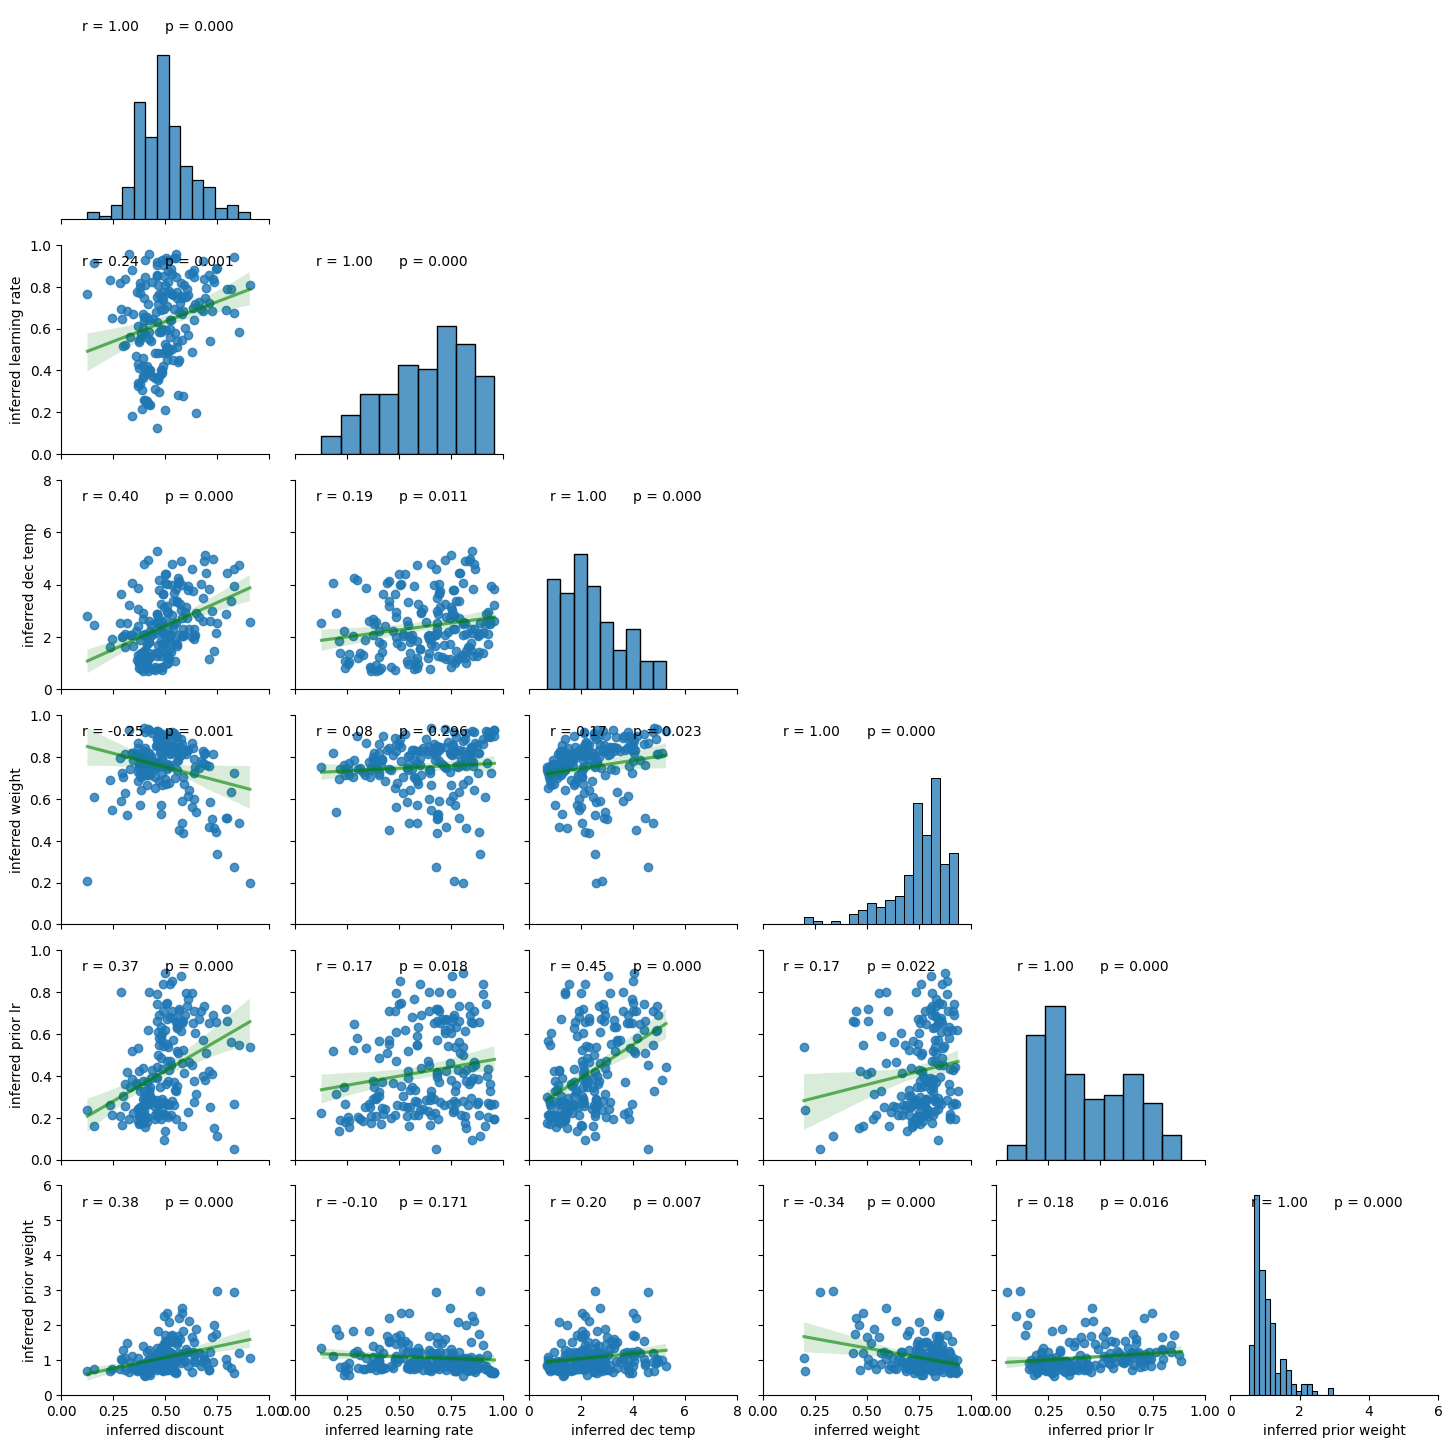

In [18]:

plt.figure()
vars_of_interest = ["inferred "+name for name in param_names]
f = sns.pairplot(data=mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    grid_kws={"layout_pad": 1.5},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
for p, p_range in enumerate(param_ranges):
    f.axes[n_pars-1,p].set_xlim(p_range)
    f.axes[p,0].set_ylim(p_range)
plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()

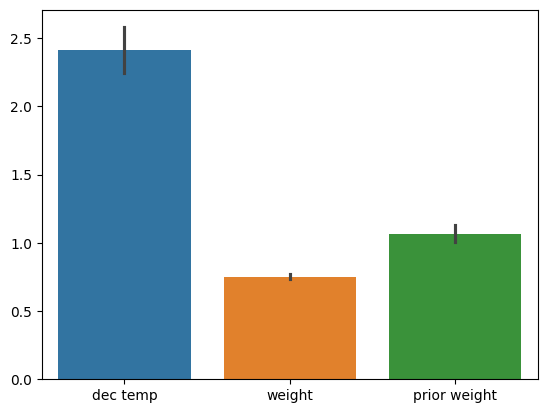

In [19]:
weight_df = pd.DataFrame({"dec temp": mean_df["inferred dec temp"], 
                            "weight": mean_df["inferred weight"], 
                            "prior weight": mean_df["inferred prior weight"]})

plt.figure()
sns.barplot(data=weight_df)
plt.show()

['inferred discount', 'inferred learning rate', 'inferred dec temp', 'inferred weight', 'inferred prior lr', 'inferred prior weight']


<Figure size 640x480 with 0 Axes>

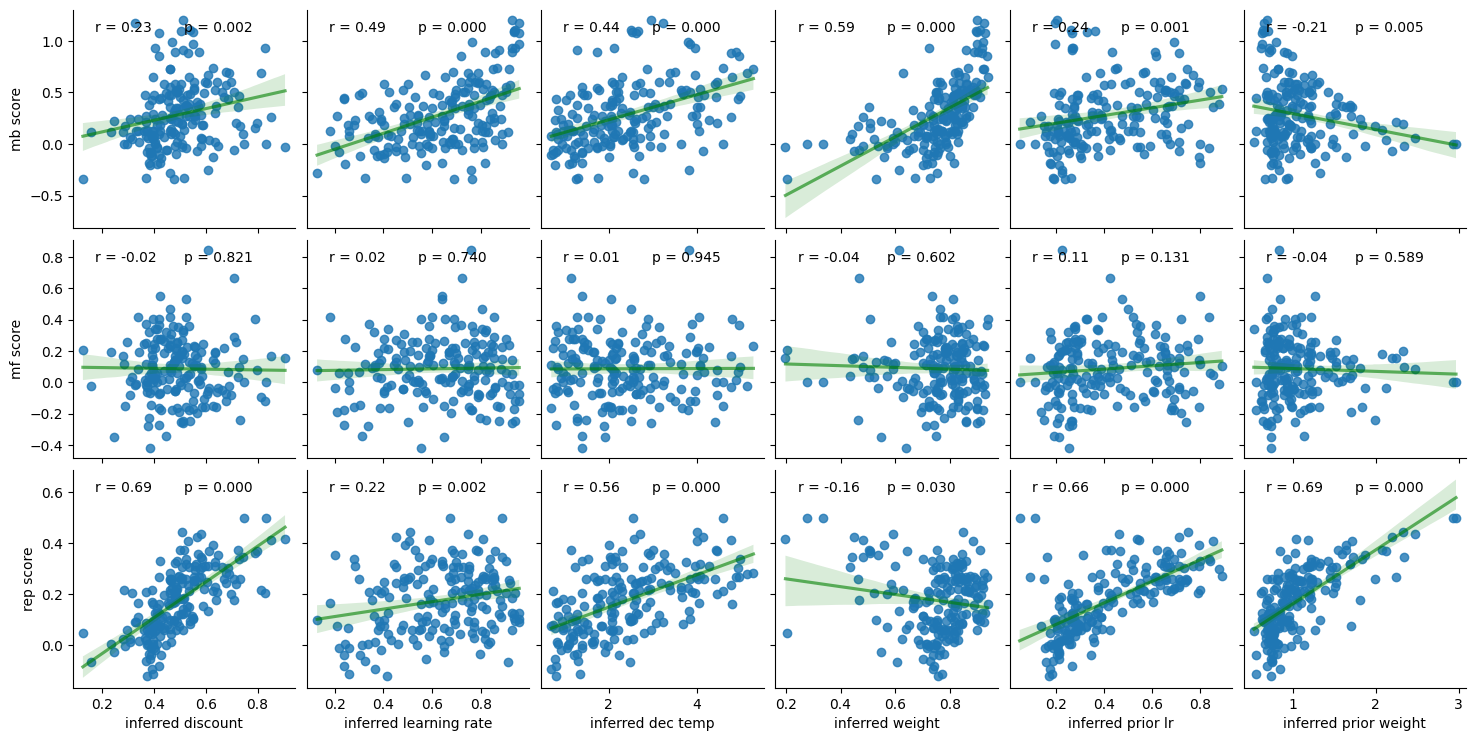

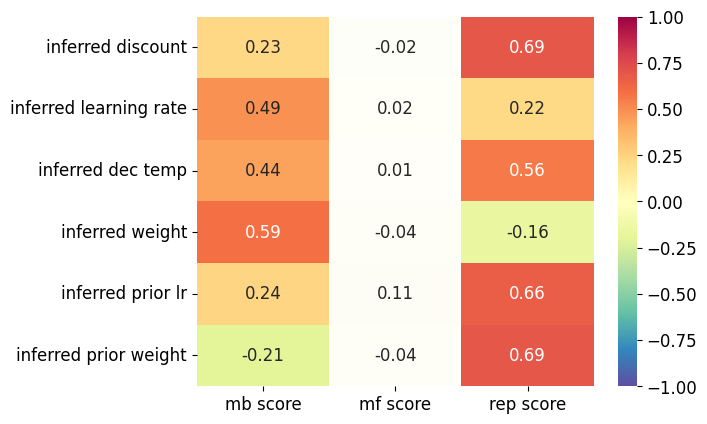

In [20]:
mean_scores_df = pd.concat([mean_df, scores_df], axis='columns')#, join="inner")

plt.figure()
x_vars_of_interest = ["inferred "+name for name in param_names]
print(x_vars_of_interest)
y_vars_of_interest = list(scores_df.keys())
f = sns.pairplot(data=mean_scores_df, kind='reg', #diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=x_vars_of_interest, y_vars=y_vars_of_interest)
f.map(tu.annot_corrfunc)
#for p, p_range in enumerate(param_plot_ranges):
#    f.axes[2,p].set_xlim(p_range)
#    f.axes[p,0].set_ylim(p_range)
#plt.title("BCC3 analysis 1 correlations with scores")
plt.show()

iu.plot_correlations(mean_scores_df, x_vars_of_interest, y_vars_of_interest)

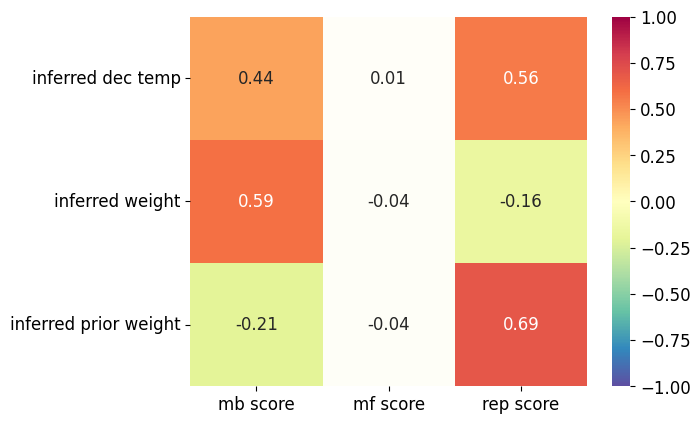

In [21]:
weight_names = ["inferred dec temp", "inferred weight", "inferred prior weight"]

iu.plot_correlations(mean_scores_df, weight_names, y_vars_of_interest)